In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from siuba import *
import plotly.express as px
import calendar
import plotly.graph_objects as go
from siuba.dply.vector import * 
import dask.dataframe as dd
import plotly.graph_objects as go


In [3]:
import dask.dataframe as dd

**1. CONSTRUCCIÓN DEL DATASET COMPLETO PARA EL TRABAJO: CARGA DE DATOS Y MODIFICACIONES SOBRE ELLOS**

Los datos se conforman por tres fuentes distintas de datos (CSV, Excel y JSON). 

In [4]:
vuelos = pd.read_csv("data/flight_data_2024_sample.csv")
vuelos

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,151.0,144.0,119.0,835.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,286.0,273.0,253.0,1773.0,0,0,0,0,0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,59.0,50.0,29.0,106.0,0,0,0,0,0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,...,0,180.0,177.0,163.0,1099.0,0,0,0,0,0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,...,0,90.0,96.0,76.0,399.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2024,1,16,2,2024-01-16,WN,3692.0,KOA,"Kona, HI",Hawaii,...,1,40.0,NaN,NaN,84.0,0,0,0,0,0
9996,2024,7,5,5,2024-07-05,AA,1924.0,LAS,"Las Vegas, NV",Nevada,...,0,226.0,244.0,183.0,1514.0,0,0,15,0,0
9997,2024,2,28,3,2024-02-28,MQ,3418.0,AUS,"Austin, TX",Texas,...,0,157.0,148.0,128.0,977.0,0,0,0,0,0
9998,2024,2,18,7,2024-02-18,DL,1117.0,ATL,"Atlanta, GA",Georgia,...,0,140.0,121.0,101.0,761.0,0,0,0,0,0


In [5]:
with open('data/Airports.json', 'r', encoding='utf-8') as file:
    json1 = json.load(file)
print(json.dumps(json1, indent=1, ensure_ascii =False)) 


[
 {
  "Rank": 1,
  "Airport": "United States Hartsfield–Jackson Atlanta International Airport",
  "Location": "Atlanta, Georgia",
  "Country": "United States",
  "Code": "ATL/KATL",
  "Passengers": 104171935,
  "Year": 2016
 },
 {
  "Rank": 2,
  "Airport": "China Beijing Capital International Airport",
  "Location": "Chaoyang-Shunyi, Beijing",
  "Country": "China",
  "Code": "PEK/ZBAA",
  "Passengers": 94393454,
  "Year": 2016
 },
 {
  "Rank": 3,
  "Airport": "United Arab Emirates Dubai International Airport",
  "Location": "Garhoud, Dubai",
  "Country": "United Arab Emirates",
  "Code": "DXB/OMDB",
  "Passengers": 83654250,
  "Year": 2016
 },
 {
  "Rank": 4,
  "Airport": "United States Los Angeles International Airport",
  "Location": "Los Angeles, California",
  "Country": "United States",
  "Code": "LAX/KLAX",
  "Passengers": 80921527,
  "Year": 2016
 },
 {
  "Rank": 5,
  "Airport": "Japan Tokyo Haneda Airport",
  "Location": "Ōta, Tokyo",
  "Country": "Japan",
  "Code": "HND/RJTT"

In [6]:
type(json1)
json1df = pd.json_normalize(json1)
json1df.head()

,Rank,Airport,Location,Country,Code,Passengers,Year
0,1,United States Hartsfield–Jackson Atlanta Inter...,"Atlanta, Georgia",United States,ATL/KATL,104171935,2016
1,2,China Beijing Capital International Airport,"Chaoyang-Shunyi, Beijing",China,PEK/ZBAA,94393454,2016
2,3,United Arab Emirates Dubai International Airport,"Garhoud, Dubai",United Arab Emirates,DXB/OMDB,83654250,2016
3,4,United States Los Angeles International Airport,"Los Angeles, California",United States,LAX/KLAX,80921527,2016
4,5,Japan Tokyo Haneda Airport,"Ōta, Tokyo",Japan,HND/RJTT,79699762,2016


In [7]:
json1df[['Code', 'code_icao']] = json1df['Code'].str.split('/', expand=True)
json1df[['Code', 'code_icao']].head()

,Code,code_icao
0,ATL,KATL
1,PEK,ZBAA
2,DXB,OMDB
3,LAX,KLAX
4,HND,RJTT


In [8]:
json1df

,Rank,Airport,Location,Country,Code,Passengers,Year,code_icao
0,1,United States Hartsfield–Jackson Atlanta Inter...,"Atlanta, Georgia",United States,ATL,104171935,2016,KATL
1,2,China Beijing Capital International Airport,"Chaoyang-Shunyi, Beijing",China,PEK,94393454,2016,ZBAA
2,3,United Arab Emirates Dubai International Airport,"Garhoud, Dubai",United Arab Emirates,DXB,83654250,2016,OMDB
3,4,United States Los Angeles International Airport,"Los Angeles, California",United States,LAX,80921527,2016,KLAX
4,5,Japan Tokyo Haneda Airport,"Ōta, Tokyo",Japan,HND,79699762,2016,RJTT
5,6,United States O'Hare International Airport,"Chicago, Illinois",United States,ORD,78327479,2016,KORD
6,7,United Kingdom Heathrow Airport,"Hillingdon, London",United Kingdom,LHR,75715474,2016,EGLL
7,8,Hong Kong Hong Kong International Airport,"Chek Lap Kok, Islands, New Territories","Hong Kong SAR, China",HKG,70314462,2016,VHHH
8,9,China Shanghai Pudong International Airport,"Pudong, Shanghai",China,PVG,66002414,2016,ZSPD
9,10,France Charles de Gaulle Airport,"Roissy-en-France, Île-de-France",France,CDG,65933145,2016,LFPG


In [9]:
data = pd.ExcelFile('data/us-airports.xlsx')
df_airports = data.parse(0) 
df_airports.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,country_name,iso_country,...,scheduled_service,gps_code,icao_code,iata_code,local_code,home_link,wikipedia_link,keywords,score,last_updated
0,3632,KLAX,large_airport,Los Angeles International Airport,33.942501,-118.407997,125.0,NaN,United States,US,...,1,KLAX,KLAX,LAX,LAX,https://www.flylax.com/,https://en.wikipedia.org/wiki/Los_Angeles_Inte...,Tom Bradley,1335475.0,2024-04-02T16:36:13+00:00
1,3754,KORD,large_airport,Chicago O'Hare International Airport,41.978600,-87.904800,680.0,NaN,United States,US,...,1,KORD,KORD,ORD,ORD,https://www.flychicago.com/ohare/home/pages/de...,https://en.wikipedia.org/wiki/O'Hare_Internati...,"CHI, Orchard Place",1503175.0,2024-03-09T23:28:49+00:00
2,3622,KJFK,large_airport,John F. Kennedy International Airport,40.639447,-73.779317,13.0,NaN,United States,US,...,1,KJFK,KJFK,JFK,JFK,https://www.jfkairport.com/,https://en.wikipedia.org/wiki/John_F._Kennedy_...,"Manhattan, New York City, NYC, Idlewild, IDL, ...",1052075.0,2026-01-12T15:26:18+00:00
3,3384,KATL,large_airport,Hartsfield Jackson Atlanta International Airport,33.636700,-84.428101,1026.0,NaN,United States,US,...,1,KATL,KATL,ATL,ATL,https://www.atl.com,https://en.wikipedia.org/wiki/Hartsfield–Jacks...,NaN,2002475.0,2025-09-12T16:52:18+00:00
4,3878,KSFO,large_airport,San Francisco International Airport,37.619806,-122.374821,13.0,NaN,United States,US,...,1,KSFO,KSFO,SFO,SFO,http://www.flysfo.com/,https://en.wikipedia.org/wiki/San_Francisco_In...,"QSF, QBA",1112475.0,2024-04-02T16:43:50+00:00


Rellenar los datos NaN que posee la columna 'score':

In [10]:
df_airports['score'] = df_airports['score'].fillna(method='ffill')
print(df_airports['score'].isna().sum())

0


In [11]:
vuelos_final = vuelos.merge(json1df, left_on='origin', right_on='Code', how='left') \
                    .merge(df_airports, left_on='origin', right_on='local_code', how='left')

In [12]:
columnas_a_eliminar = [
    'Location', 'Country', 'Code', 'id', 'ident', 
    'continent', 'iso_country', 'iso_region', 'local_region', 
    'municipality', 'scheduled_service', 'gps_code', 'icao_code', 
    'iata_code', 'local_code', 'keywords', 'last_updated', 'country_name', 'Year'
    , 'name', 'elevation_ft', 'home_link', 'wikipedia_link', 'region_name', 'cancellation_code']

vuelos = vuelos_final.drop(columns=columnas_a_eliminar)
vuelos.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,security_delay,late_aircraft_delay,Rank,Airport,Passengers,code_icao,type,latitude_deg,longitude_deg,score
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,0,11.0,United States Dallas/Fort Worth International ...,65670697.0,KDFW,large_airport,32.896801,-97.038002,1203175.0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,0,31.0,United States Charlotte Douglas International ...,44422022.0,KCLT,large_airport,35.214001,-80.943100,1028075.0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,0,NaN,NaN,NaN,NaN,medium_airport,35.035301,-85.203796,750.0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,...,0,0,NaN,NaN,NaN,NaN,large_airport,41.303200,-95.894096,1000.0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,...,0,0,NaN,NaN,NaN,NaN,large_airport,39.175400,-76.668297,1015475.0


**LECTURA DE LOS DATOS MEDIANTE DASK**

In [13]:
import dask.dataframe as dd
vuelos = dd.from_pandas(vuelos, npartitions=4)
vuelos.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,security_delay,late_aircraft_delay,Rank,Airport,Passengers,code_icao,type,latitude_deg,longitude_deg,score
0,2024,4,18,4,2024-04-18,MQ,3535.0,DFW,"Dallas/Fort Worth, TX",Texas,...,0,0,11.0,United States Dallas/Fort Worth International ...,65670697.0,KDFW,large_airport,32.896801,-97.038002,1203175.0
1,2024,1,1,1,2024-01-01,AA,148.0,CLT,"Charlotte, NC",North Carolina,...,0,0,31.0,United States Charlotte Douglas International ...,44422022.0,KCLT,large_airport,35.214001,-80.943100,1028075.0
2,2024,12,12,4,2024-12-12,9E,5440.0,CHA,"Chattanooga, TN",Tennessee,...,0,0,NaN,<NA>,NaN,<NA>,medium_airport,35.035301,-85.203796,750.0
3,2024,4,8,1,2024-04-08,WN,1971.0,OMA,"Omaha, NE",Nebraska,...,0,0,NaN,<NA>,NaN,<NA>,large_airport,41.303200,-95.894096,1000.0
4,2024,2,16,5,2024-02-16,WN,862.0,BWI,"Baltimore, MD",Maryland,...,0,0,NaN,<NA>,NaN,<NA>,large_airport,39.175400,-76.668297,1015475.0


In [14]:
vuelos = vuelos.rename(columns={
    'op_unique_carrier': 'aerolinea',
})

vuelos['aerolinea'] = vuelos['aerolinea'].astype('category')
vuelos['origin'] = vuelos['origin'].astype('category')
vuelos['dest'] = vuelos['dest'].astype('category')
vuelos['origin_state_nm'] = vuelos['origin_state_nm'].astype('category')
vuelos['dest_state_nm'] = vuelos['dest_state_nm'].astype('category')

vuelos['cancelled'] = vuelos['cancelled'].astype(bool)
vuelos['diverted'] = vuelos['diverted'].astype(bool)

vuelos['is_delayed'] = (vuelos['arr_delay'] > 15).astype(int)
vuelos['fl_date'] = dd.to_datetime(vuelos['fl_date'])

Creación de una nueva variable **tipo_retraso**, según los minutos de retraso.

In [15]:
def clasificar_retraso(minutos):
    if minutos < -5:
        return 'Adelantado'
    elif minutos <= 5:
        return 'En tiempo'
    else:
        return 'Retrasado'

vuelos['tipo_retraso'] = vuelos['arr_delay'].apply(clasificar_retraso)

/opt/anaconda3/lib/python3.11/site-packages/dask/dataframe/core.py:4522: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('arr_delay', 'object'))

  warnings.warn(meta_warning(meta))


LO GUARDAMOS EN FORMATO FEATHER

In [16]:
type(vuelos)
vuelos_pd_streamlit = vuelos.compute()
vuelos_pd_streamlit.to_feather('vuelos_2024_sample.feather')

**2. ANÁLISIS DE LOS DATOS: ESTADÍSTICAS Y PLOTTING**

In [17]:
vuelos['tipo_retraso'].value_counts().compute()

tipo_retraso
Adelantado    5062
Retrasado     3031
En tiempo     1907
Name: count, dtype: int64[pyarrow]

In [18]:
vuelos['tipo_retraso'].value_counts(normalize=True).round(3).compute() * 100

tipo_retraso
Adelantado    50.6
Retrasado     30.3
En tiempo     19.1
Name: proportion, dtype: double[pyarrow]

In [19]:
vuelos['arr_delay'].describe().compute()

count    9836.000000
mean        7.545039
std        55.803223
min       -78.000000
25%       -14.000000
50%        -6.000000
75%        10.000000
max      2014.000000
Name: arr_delay, dtype: float64

In [20]:
resultado = vuelos["arr_delay"].quantile(0.7).compute()
print(resultado)

6.0


In [21]:
df_resumen1 = vuelos.groupby("aerolinea")[["dep_delay","arr_delay"]].mean().compute()
df_resumen2 = vuelos.groupby("aerolinea")[["dep_delay", "arr_delay"]].agg([min, max, sum]).compute()
df_resumen = pd.concat([df_resumen1, df_resumen2], axis=1)
df_resumen

,dep_delay,arr_delay,"(dep_delay, min)","(dep_delay, max)","(dep_delay, sum)","(arr_delay, min)","(arr_delay, max)","(arr_delay, sum)"
aerolinea,,,,,,,,
9E,10.615385,4.077206,-17.0,653.0,2898.0,-50.0,637.0,1109.0
AA,21.993402,16.198529,-16.0,2011.0,29999.0,-78.0,2014.0,22030.0
AS,5.487500,3.104762,-18.0,166.0,1756.0,-52.0,179.0,978.0
B6,17.587879,11.411585,-18.0,649.0,5804.0,-51.0,641.0,3743.0
DL,10.157931,3.545392,-20.0,534.0,14729.0,-64.0,522.0,5116.0
F9,18.861111,15.899306,-19.0,516.0,5432.0,-51.0,500.0,4579.0
G4,12.841176,9.729412,-22.0,547.0,2183.0,-42.0,544.0,1654.0
HA,1.840426,0.425532,-10.0,79.0,173.0,-33.0,79.0,40.0
MQ,8.446650,4.892231,-14.0,326.0,3404.0,-39.0,321.0,1952.0


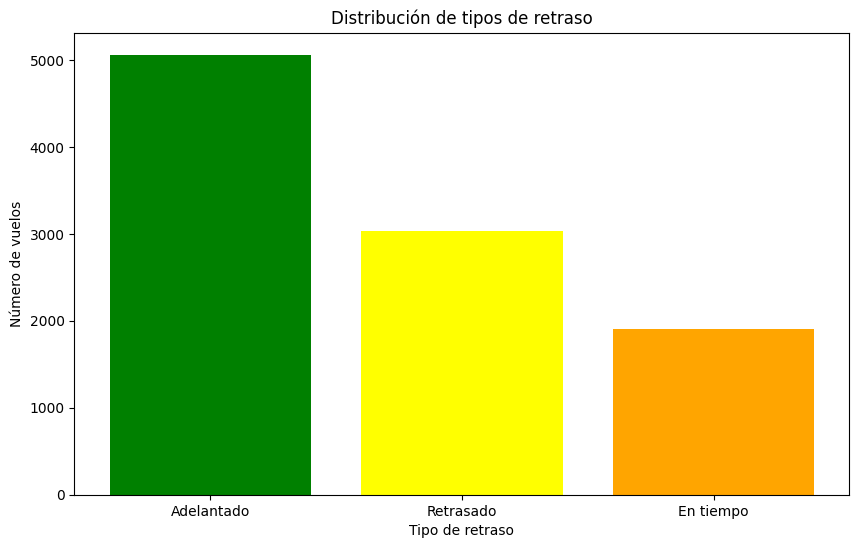

In [22]:
conteos = vuelos['tipo_retraso'].value_counts().compute()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(conteos.index, conteos.values, color=['green', 'yellow', 'orange', 'red','pink'])
ax.set_title('Distribución de tipos de retraso')
ax.set_xlabel('Tipo de retraso')
ax.set_ylabel('Número de vuelos')
plt.show()

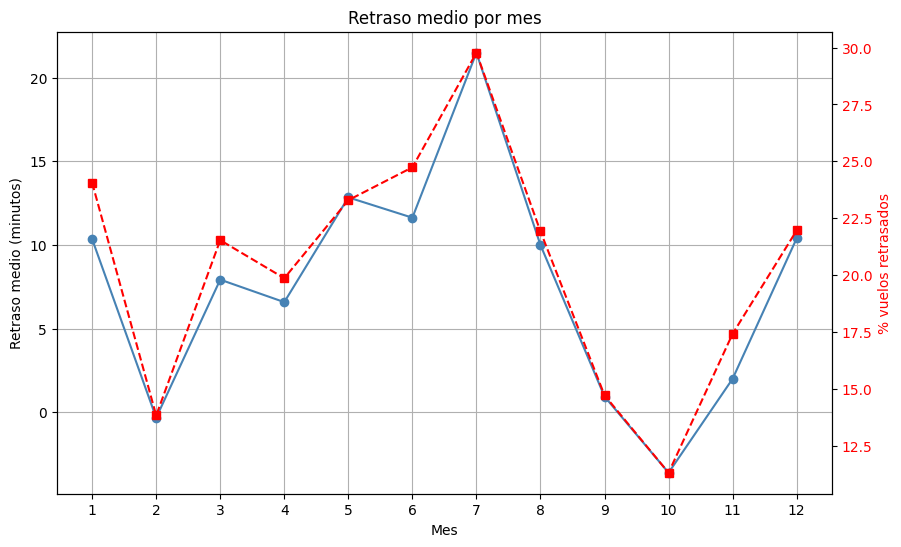

In [23]:
retraso_mes = vuelos.groupby('month')['arr_delay'].mean().compute()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot((retraso_mes.index), retraso_mes.values, marker='o', color='steelblue')
ax.set_title('Retraso medio por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Retraso medio (minutos)')
ax.set_xticks(range(1, 13))
ax.grid(True)

pct_retrasados = vuelos.groupby('month')['is_delayed'].mean().compute() * 100
ax2 = ax.twinx()
ax2.plot((retraso_mes.index), pct_retrasados.values, 
         color='red', marker='s', linestyle='--', label='% retrasados')
ax2.set_ylabel('% vuelos retrasados', color='red')
ax2.tick_params(axis='y', labelcolor='red')
 
plt.show()

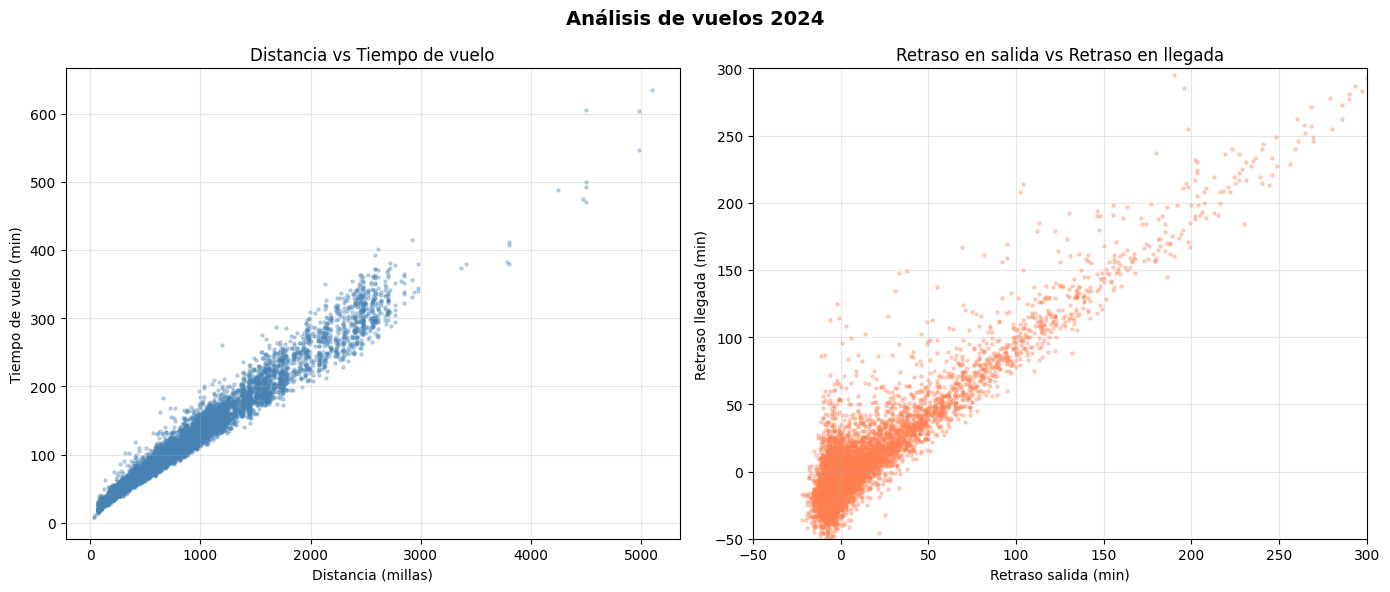

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(vuelos['distance'], vuelos['air_time'], 
            alpha=0.3, s=5, color='steelblue')
ax1.set_title('Distancia vs Tiempo de vuelo')
ax1.set_xlabel('Distancia (millas)')
ax1.set_ylabel('Tiempo de vuelo (min)')
ax1.grid(True, alpha=0.3)

ax2.scatter(vuelos['dep_delay'], vuelos['arr_delay'], 
            alpha=0.3, s=5, color='coral')
ax2.set_title('Retraso en salida vs Retraso en llegada')
ax2.set_xlabel('Retraso salida (min)')
ax2.set_ylabel('Retraso llegada (min)')
ax2.set_xlim(-50, 300)
ax2.set_ylim(-50, 300)
ax2.grid(True, alpha=0.3)

fig.suptitle('Análisis de vuelos 2024', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
retraso_aerolinea = vuelos.groupby('aerolinea')['arr_delay'].mean().reset_index().compute()
retraso_aerolinea.columns = ['aerolinea', 'retraso_medio']
retraso_aerolinea = retraso_aerolinea.sort_values('retraso_medio', ascending=False)

fig = px.bar(retraso_aerolinea, 
             x='aerolinea', y='retraso_medio',
             title='Retraso medio por aerolínea',
             labels={'retraso_medio': 'Retraso medio (min)', 'aerolinea': 'Aerolínea'},
             color='retraso_medio',
             color_continuous_scale='RdYlGn_r')
fig.show()

In [26]:
import plotly.graph_objects as go

causas = {
    'Aerolínea': vuelos['carrier_delay'].sum(),
    'Clima': vuelos['weather_delay'].sum(),
    'Sistema aéreo': vuelos['nas_delay'].sum(),
    'Seguridad': vuelos['security_delay'].sum(),
    'Avión previo': vuelos['late_aircraft_delay'].sum()
}

fig = go.Figure(data=[go.Pie(
    labels=list(causas.keys()),
    values=list(causas.values())
)])
fig.update_layout(title='Causas principales de retraso')
fig.show()

In [27]:
top_4_aerolineas = vuelos['aerolinea'].value_counts().nlargest(4).index.compute().tolist()

filtro_vuelos = vuelos[
    (vuelos['aerolinea'].isin(top_4_aerolineas)) & 
    (vuelos['arr_delay'].between(-60, 180))
]


vuelos_para_grafico = filtro_vuelos.compute()

fig = px.violin(vuelos_para_grafico, 
                y='arr_delay', 
                x='aerolinea', 
                title='Distribución de retrasos para las 4 aerolíneas principales (Datos completos)',
                labels={'arr_delay': 'Retraso en llegada (min)', 'aerolinea': 'Aerolínea'},
                box=True, 
                points=False)

fig.show()

In [28]:
print(vuelos.columns)

Index(['year', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'aerolinea',
       'op_carrier_fl_num', 'origin', 'origin_city_name', 'origin_state_nm',
       'dest', 'dest_city_name', 'dest_state_nm', 'crs_dep_time', 'dep_time',
       'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in',
       'crs_arr_time', 'arr_time', 'arr_delay', 'cancelled', 'diverted',
       'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance',
       'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay',
       'late_aircraft_delay', 'Rank', 'Airport', 'Passengers', 'code_icao',
       'type', 'latitude_deg', 'longitude_deg', 'score', 'is_delayed',
       'tipo_retraso'],
      dtype='object')


In [29]:
mapa_meses = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

vuelos['nombre_mes'] = vuelos['month'].map(mapa_meses)

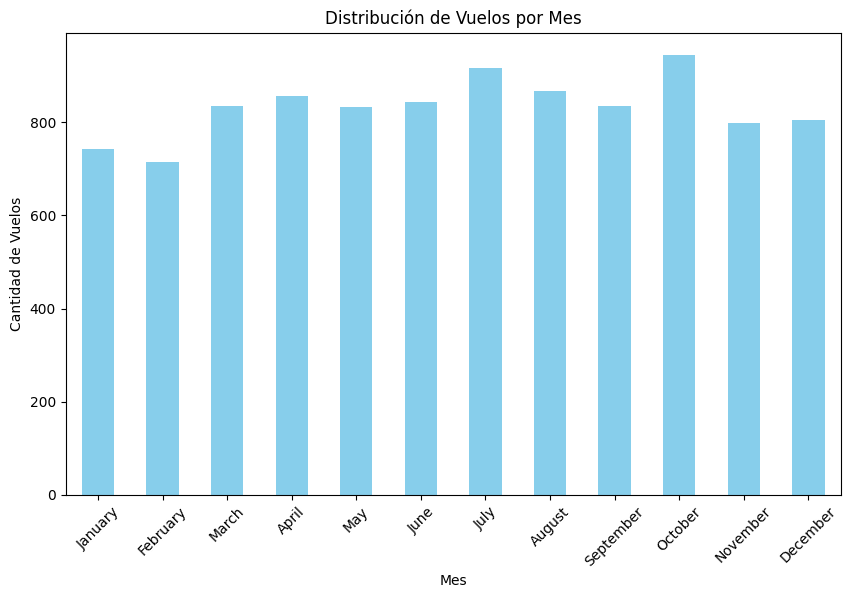

In [30]:
conteo_meses = vuelos['nombre_mes'].value_counts().compute()
orden_meses = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
conteo_meses = conteo_meses.reindex(orden_meses)

conteo_meses.plot(kind='bar', color='skyblue', figsize=(10, 6))
plt.title('Distribución de Vuelos por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Vuelos')
plt.xticks(rotation=45)
plt.show()

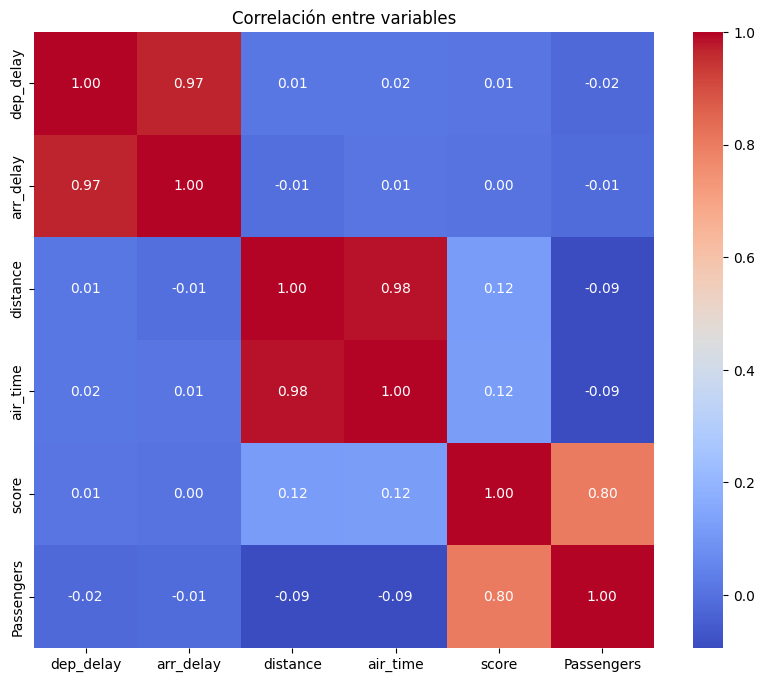

In [31]:
columnas_numericas = ['dep_delay', 'arr_delay', 'distance', 
                'air_time', 'score', 'Passengers']

plt.figure(figsize=(10,8))
sns.heatmap(vuelos[columnas_numericas].corr().compute(), 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlación entre variables")
plt.show()

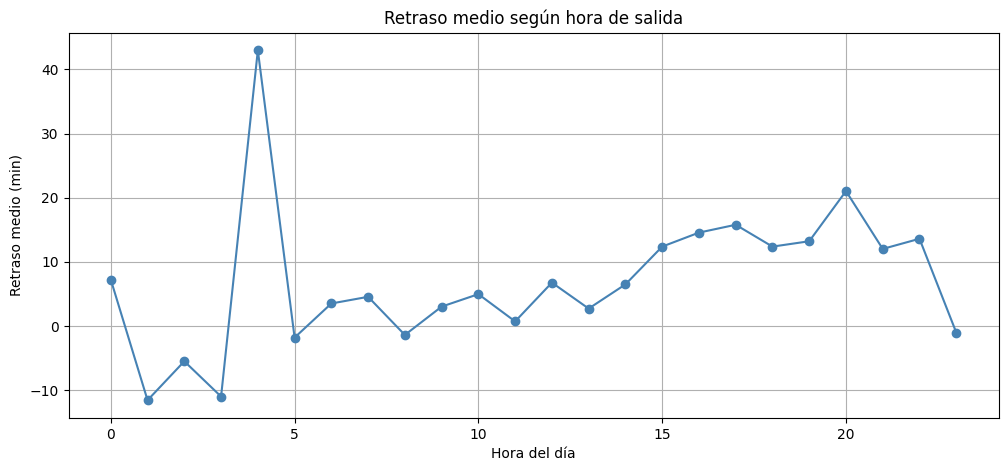

In [32]:
vuelos['hora_salida'] = vuelos['crs_dep_time'] // 100
retraso_por_hora = vuelos.groupby('hora_salida')['arr_delay'].mean().compute()
retraso_por_hora = retraso_por_hora.sort_index().sort_index()

retraso_por_hora.plot(
    kind='line',
    figsize=(12, 5),
    marker='o',
    color='steelblue'
)

plt.title("Retraso medio según hora de salida")
plt.xlabel("Hora del día")
plt.ylabel("Retraso medio (min)")
plt.grid(True)
plt.show()

Existencia de ciertos valores NaN en la columna arr_delay que es la que empezaremos a analizar. Optamos por quitarlos directamente del dataset porque son escasos y no van a alterar el dataset apenas. 

In [33]:
vuelos.isna().sum().compute()


year                      0
month                     0
day_of_month              0
day_of_week               0
fl_date                   0
aerolinea                 0
op_carrier_fl_num         0
origin                    0
origin_city_name          0
origin_state_nm           0
dest                      0
dest_city_name            0
dest_state_nm             0
crs_dep_time              0
dep_time                116
dep_delay               116
taxi_out                120
wheels_off              120
wheels_on               127
taxi_in                 127
crs_arr_time              0
arr_time                127
arr_delay               164
cancelled                 0
diverted                  0
crs_elapsed_time          0
actual_elapsed_time     164
air_time                164
distance                  0
carrier_delay             0
weather_delay             0
nas_delay                 0
security_delay            0
late_aircraft_delay       0
Rank                   5632
Airport             

In [34]:
vuelos = vuelos.dropna(subset=['arr_delay'])
vuelos.isna().sum().compute() 

year                      0
month                     0
day_of_month              0
day_of_week               0
fl_date                   0
aerolinea                 0
op_carrier_fl_num         0
origin                    0
origin_city_name          0
origin_state_nm           0
dest                      0
dest_city_name            0
dest_state_nm             0
crs_dep_time              0
dep_time                  0
dep_delay                 0
taxi_out                  0
wheels_off                0
wheels_on                 0
taxi_in                   0
crs_arr_time              0
arr_time                  0
arr_delay                 0
cancelled                 0
diverted                  0
crs_elapsed_time          0
actual_elapsed_time       0
air_time                  0
distance                  0
carrier_delay             0
weather_delay             0
nas_delay                 0
security_delay            0
late_aircraft_delay       0
Rank                   5539
Airport             

Volvemos al formato pandas para trabajar más comodámente con los plots y la librería **siuba**.

In [35]:
vuelos_pandas = vuelos.compute()
print(type(vuelos_pandas))

<class 'pandas.core.frame.DataFrame'>


In [36]:
top_rutas = (vuelos_pandas
    >> filter(_.cancelled == 0)
    >> group_by(_.origin_city_name, _.dest_city_name)
    >> summarize(retraso_medio = _.arr_delay.mean(), n_vuelos = n(_))
) 

top_rutas.sort_values(
    by=['retraso_medio', 'n_vuelos'], 
    ascending=[False, False]
).head(10)[['origin_city_name', 'dest_city_name', 'retraso_medio', 'n_vuelos']]


,origin_city_name,dest_city_name,retraso_medio,n_vuelos
1774,"Louisville, KY","Miami, FL",2014.000000,1
2847,"San Francisco, CA","Monterey, CA",664.000000,1
1098,"Des Moines, IA","Santa Ana, CA",544.000000,1
3307,"Wichita, KS","Houston, TX",487.000000,2
2103,"New York, NY","Birmingham, AL",387.000000,1
1605,"Lafayette, LA","Dallas/Fort Worth, TX",363.000000,1
735,"Cleveland, OH","Las Vegas, NV",300.000000,1
515,"Charlotte, NC","Lafayette, LA",281.000000,1
3173,"Tampa, FL","Phoenix, AZ",271.000000,1
2361,"Palm Springs, CA","Phoenix, AZ",268.666667,3


In [37]:
(vuelos_pandas
 >> filter(_.cancelled == 0)
 >> group_by(_.aerolinea)
 >> summarize(retraso_medio = _.arr_delay.mean())
 >> mutate(retraso_medio = _.retraso_medio.round(1)) 
 >> arrange(-_.retraso_medio)
)

,aerolinea,retraso_medio
1,AA,16.2
5,F9,15.9
10,OH,13.6
3,B6,11.4
6,G4,9.7
11,OO,9.1
9,NK,8.5
13,WN,6.0
12,UA,5.4
8,MQ,4.9


**MESES CON MAYOR RETRASO SEGÚN LA AEROLÍNEA**

In [38]:
retraso_por_aerolinea_mes = {}
for aerolinea, grupo in vuelos_pandas.groupby('aerolinea'):
    retraso_por_aerolinea_mes[aerolinea] = grupo.groupby('nombre_mes')['arr_delay'].mean().to_dict()

umbral = 15

meses_problematicos = {
    aerolinea: [
        {'mes': nombre_mes, 'retraso_medio': round(retraso, 1)}
        for nombre_mes, retraso in info_meses.items()
        if retraso > umbral
    ]
    for aerolinea, info_meses in retraso_por_aerolinea_mes.items()
}

print(f"Aerolíneas con meses de retraso medio > {umbral} min:")
for aerolinea, meses in meses_problematicos.items():
    if meses:
        detalles = ', '.join([f"{m['mes']} ({m['retraso_medio']})" for m in meses])
        print(f"  {aerolinea}: {detalles}")

Aerolíneas con meses de retraso medio > 15 min:
  9E: January (59.4), July (29.5), May (16.0)
  AA: July (45.1), June (35.9), March (23.9), May (24.7)
  AS: March (20.1)
  B6: January (19.5), July (21.2), March (29.1), May (28.5)
  DL: July (21.1)
  F9: April (28.7), August (25.3), December (19.1), July (22.8), June (44.9), March (18.4), May (15.5), September (19.6)
  G4: August (26.7), February (19.1), May (39.8)
  MQ: July (15.6)
  NK: August (22.4), February (26.2), July (15.8), March (21.6)
  OH: December (29.8), January (22.9), July (32.9), September (25.5)
  OO: December (24.9), July (21.7), November (18.3)
  UA: April (20.3), July (23.0)
  WN: January (18.1)


**EVOLUCIÓN DE LOS RETRASOS SEGÚN EL MES**

In [39]:
resumen_mensual = vuelos_pandas.groupby('month').agg({
    'arr_delay': 'mean',
    'nombre_mes': 'first'  
}).reset_index()

retrasos = resumen_mensual['arr_delay'].tolist()
nombres = resumen_mensual['nombre_mes'].tolist()

cambios_mensuales = []
for i in range(len(retrasos) - 1):
    mes_actual = nombres[i]
    mes_siguiente = nombres[i+1]
    retraso_actual = retrasos[i]
    retraso_siguiente = retrasos[i+1]
    
    cambio_valor = retraso_siguiente - retraso_actual
    pct = (cambio_valor / abs(retraso_actual)) * 100
    
    cambios_mensuales.append({
        'de_mes': mes_actual,
        'a_mes': mes_siguiente,
        'cambio': round(cambio_valor, 1),
        'pct_cambio': round(pct, 1)
    })

print("Evolución del retraso mes a mes:")
for c in cambios_mensuales:
    direccion = "↑" if c['cambio'] > 0 else "↓"
    print(f"  {c['de_mes']} → {c['a_mes']}: {direccion} {c['cambio']:+.1f} min ({c['pct_cambio']:+.1f}%)")

Evolución del retraso mes a mes:
  January → February: ↓ -10.7 min (-103.2%)
  February → March: ↑ +8.3 min (+2480.9%)
  March → April: ↓ -1.3 min (-17.0%)
  April → May: ↑ +6.3 min (+95.2%)
  May → June: ↓ -1.2 min (-9.5%)
  June → July: ↑ +9.9 min (+84.8%)
  July → August: ↓ -11.5 min (-53.5%)
  August → September: ↓ -9.1 min (-90.6%)
  September → October: ↓ -4.6 min (-487.1%)
  October → November: ↑ +5.6 min (+155.2%)
  November → December: ↑ +8.4 min (+420.1%)


**AEROLÍNEA CON MÁS PORCENTAJE DE VUELOS RETRASADOS POR MES**

In [40]:
datos_por_mes = vuelos_pandas.groupby(['month', 'aerolinea'])['is_delayed'].mean() * 100
datos_por_mes = datos_por_mes.unstack()

peor_aerolinea_por_mes = list(map(
    lambda item: {
        'mes': item[0],
        'aerolinea': item[1].idxmax(),
        'pct_retrasados': round(item[1].max(), 1)
    },
    datos_por_mes.iterrows()
))

print("Aerolínea con mayor % de vuelos retrasados por mes:")
for item in peor_aerolinea_por_mes:
    print(f"  {calendar.month_name[int(item['mes'])]}: {item['aerolinea']} ({item['pct_retrasados']}%)")

Aerolínea con mayor % de vuelos retrasados por mes:
  January: B6 (39.1%)
  February: G4 (33.3%)
  March: F9 (34.8%)
  April: F9 (50.0%)
  May: AA (39.1%)
  June: F9 (41.2%)
  July: F9 (41.7%)
  August: NK (38.3%)
  September: G4 (41.7%)
  October: AS (28.0%)
  November: G4 (29.4%)
  December: G4 (40.0%)


**PEOR DATO DE TODOS LOS RETRASOS**

In [41]:
from functools import reduce

peor_mes_aerolinea = reduce(
    lambda acc, item: acc if acc['pct_retrasados'] > item['pct_retrasados'] else item,
    peor_aerolinea_por_mes
)

print(f"\nPeor mes y aerolínea de todo el año:")
print(f"  {calendar.month_name[int(peor_mes_aerolinea['mes'])]} - {peor_mes_aerolinea['aerolinea']} "
      f"con un {peor_mes_aerolinea['pct_retrasados']}% de vuelos retrasados")


Peor mes y aerolínea de todo el año:
  April - F9 con un 50.0% de vuelos retrasados


**PORCENTAJES DE CADA AEROLÍNEA POR MES**

In [42]:
retrasos_por_aerolinea = {}
aerolineas = list(datos_por_mes.columns)

for aerolinea in aerolineas:
    retrasos_por_aerolinea[aerolinea] = dict(map(
        lambda item: (calendar.month_name[item[0]-1], item[1]),
        datos_por_mes[aerolinea].items()
    ))

print("Retrasos de AA a lo largo del año:")
for mes, pct in retrasos_por_aerolinea['AA'].items():
    print(f"  {mes}: {pct:.1f}%") 

analisis_aerolineas = dict(map(
    lambda item: (
        item[0],  
        {
            'media': round(np.mean(list(item[1].values())), 1),
            'tendencia': round(list(item[1].values())[-1] - list(item[1].values())[0], 1),
            'peor_mes': max(item[1].items(), key=lambda x: x[1]),
            'mejor_mes': min(item[1].items(), key=lambda x: x[1])
        }
    ),
    retrasos_por_aerolinea.items()
))

print("\nAnálisis por aerolínea:")
for aerolinea, analisis in analisis_aerolineas.items():
    print(f"\n{aerolinea}:")
    print(f"  Media anual: {analisis['media']}% de vuelos retrasados")
    print(f"  Tendencia (Dic-Ene): {analisis['tendencia']:+.1f}%")
    print(f"  Peor mes: {analisis['peor_mes'][0]} ({analisis['peor_mes'][1]:.1f}%)")
    print(f"  Mejor mes: {analisis['mejor_mes'][0]} ({analisis['mejor_mes'][1]:.1f}%)")

Retrasos de AA a lo largo del año:
  : 30.0%
  January: 15.2%
  February: 32.8%
  March: 21.1%
  April: 39.1%
  May: 35.3%
  June: 37.9%
  July: 28.0%
  August: 22.2%
  September: 12.8%
  October: 24.7%
  November: 24.5%

Análisis por aerolínea:

9E:
  Media anual: 14.0% de vuelos retrasados
  Tendencia (Dic-Ene): -14.6%
  Peor mes: June (33.3%)
  Mejor mes: March (4.3%)

AA:
  Media anual: 27.0% de vuelos retrasados
  Tendencia (Dic-Ene): -5.5%
  Peor mes: April (39.1%)
  Mejor mes: September (12.8%)

AS:
  Media anual: 20.6% de vuelos retrasados
  Tendencia (Dic-Ene): -19.0%
  Peor mes:  (33.3%)
  Mejor mes: April (9.7%)

B6:
  Media anual: 25.3% de vuelos retrasados
  Tendencia (Dic-Ene): -14.9%
  Peor mes:  (39.1%)
  Mejor mes: August (10.5%)

DL:
  Media anual: 16.7% de vuelos retrasados
  Tendencia (Dic-Ene): -0.7%
  Peor mes: June (28.8%)
  Mejor mes: January (4.6%)

F9:
  Media anual: 29.8% de vuelos retrasados
  Tendencia (Dic-Ene): +0.6%
  Peor mes: March (50.0%)
  Mejor mes:

**CLASIFICACIÓN DE LOS MESES POR NIVEL DE RETRASO**

In [43]:
retraso_mensual = vuelos_pandas.groupby('month')['arr_delay'].mean().tolist()

def clasificar_cuartil(valor, todos_valores):
    q25, q50, q75 = np.percentile(todos_valores, [25, 50, 75])
    if valor <= q25:
        return 'Q1 - Muy puntual'
    elif valor <= q50:
        return 'Q2 - Puntual'
    elif valor <= q75:
        return 'Q3 - Retrasado'
    else:
        return 'Q4 - Muy retrasado'

clasificacion_meses = list(map(
    lambda item: {
        'mes': calendar.month_name[item[0]+1],
        'retraso': round(item[1], 1),
        'cuartil': clasificar_cuartil(item[1], retraso_mensual)
    },
    enumerate(retraso_mensual)
))

print("Clasificación de meses por nivel de retraso:")
for item in clasificacion_meses:
    print(f"  {item['mes']}: {item['retraso']} min → {item['cuartil']}")

Clasificación de meses por nivel de retraso:
  January: 10.4 min → Q3 - Retrasado
  February: -0.3 min → Q1 - Muy puntual
  March: 7.9 min → Q2 - Puntual
  April: 6.6 min → Q2 - Puntual
  May: 12.8 min → Q4 - Muy retrasado
  June: 11.6 min → Q4 - Muy retrasado
  July: 21.5 min → Q4 - Muy retrasado
  August: 10.0 min → Q3 - Retrasado
  September: 0.9 min → Q1 - Muy puntual
  October: -3.6 min → Q1 - Muy puntual
  November: 2.0 min → Q2 - Puntual
  December: 10.4 min → Q3 - Retrasado


**INFORME COMPLETO POR AEROLÍNEA**

In [44]:
def crear_informe_aerolinea(aerolinea, datos):
    """Genera un informe completo para una aerolínea"""
    valores = list(datos.values())
    meses = list(datos.keys())
    return {
        'aerolinea': aerolinea,
        'pct_medio_anual': round(np.mean(valores), 1),
        'peor_mes': {
            'nombre': meses[valores.index(max(valores))],
            'pct': round(max(valores), 1)
        },
        'mejor_mes': {
            'nombre': meses[valores.index(min(valores))],
            'pct': round(min(valores), 1)
        },
        'variabilidad': round(np.std(valores), 1),
        'retrasos_por_trimestre': [
            round(np.mean(valores[0:3]), 1),   # Q1: Ene-Mar
            round(np.mean(valores[3:6]), 1),   # Q2: Abr-Jun
            round(np.mean(valores[6:9]), 1),   # Q3: Jul-Sep
            round(np.mean(valores[9:12]), 1)   # Q4: Oct-Dic
        ],
        'tendencia': 'empeora' if valores[-1] > valores[0] else 'mejora'
    }

informes_aerolineas = list(map(
    lambda item: crear_informe_aerolinea(item[0], item[1]),
    retrasos_por_aerolinea.items()
))

# Mostrar informe completo
print("=" * 70)
print("INFORME COMPLETO DE RETRASOS POR AEROLÍNEA — 2024")
print("=" * 70)

for informe in informes_aerolineas:
    print(f"\n{informe['aerolinea']}:")
    print(f"  Media anual de retrasos: {informe['pct_medio_anual']}%")
    print(f"  Peor mes: {informe['peor_mes']['nombre']} ({informe['peor_mes']['pct']}%)")
    print(f"  Mejor mes: {informe['mejor_mes']['nombre']} ({informe['mejor_mes']['pct']}%)")
    print(f"  Variabilidad (σ): {informe['variabilidad']}")
    print(f"  Retrasos por trimestre: Q1={informe['retrasos_por_trimestre'][0]}%, "
          f"Q2={informe['retrasos_por_trimestre'][1]}%, "
          f"Q3={informe['retrasos_por_trimestre'][2]}%, "
          f"Q4={informe['retrasos_por_trimestre'][3]}%")
    print(f"  Tendencia (Ene→Dic): {informe['tendencia']}")

print("\n" + "=" * 70)
print("CONCLUSIONES CLAVE:")
print("=" * 70)

peor_aerolinea = max(informes_aerolineas, key=lambda x: x['pct_medio_anual'])
mejor_aerolinea = min(informes_aerolineas, key=lambda x: x['pct_medio_anual'])
mas_variable = max(informes_aerolineas, key=lambda x: x['variabilidad'])

print(f"Aerolínea con más retrasos: {peor_aerolinea['aerolinea']} ({peor_aerolinea['pct_medio_anual']}%)")
print(f"Aerolínea más puntual: {mejor_aerolinea['aerolinea']} ({mejor_aerolinea['pct_medio_anual']}%)")
print(f"Aerolínea más irregular: {mas_variable['aerolinea']} (σ={mas_variable['variabilidad']})")
print("=" * 70)

INFORME COMPLETO DE RETRASOS POR AEROLÍNEA — 2024

9E:
  Media anual de retrasos: 14.0%
  Peor mes: June (33.3%)
  Mejor mes: March (4.3%)
  Variabilidad (σ): 8.6
  Retrasos por trimestre: Q1=17.0%, Q2=10.7%, Q3=18.0%, Q4=10.4%
  Tendencia (Ene→Dic): mejora

AA:
  Media anual de retrasos: 27.0%
  Peor mes: April (39.1%)
  Mejor mes: September (12.8%)
  Variabilidad (σ): 8.1
  Retrasos por trimestre: Q1=26.0%, Q2=31.8%, Q3=29.4%, Q4=20.7%
  Tendencia (Ene→Dic): mejora

AS:
  Media anual de retrasos: 20.6%
  Peor mes:  (33.3%)
  Mejor mes: April (9.7%)
  Variabilidad (σ): 7.8
  Retrasos por trimestre: Q1=26.4%, Q2=19.8%, Q3=18.3%, Q4=17.9%
  Tendencia (Ene→Dic): mejora

B6:
  Media anual de retrasos: 25.3%
  Peor mes:  (39.1%)
  Mejor mes: August (10.5%)
  Variabilidad (σ): 8.1
  Retrasos por trimestre: Q1=30.3%, Q2=24.9%, Q3=23.0%, Q4=23.1%
  Tendencia (Ene→Dic): mejora

DL:
  Media anual de retrasos: 16.7%
  Peor mes: June (28.8%)
  Mejor mes: January (4.6%)
  Variabilidad (σ): 7.0
  R

Utilizamos el formato de datos en largo para analizar las causas del retraso:

In [45]:
vuelos_largo = vuelos_pandas.melt(
    id_vars=['month', 'aerolinea', 'origin', 'dest', 'is_delayed'],
    value_vars=['carrier_delay', 'weather_delay', 'nas_delay', 
                'security_delay', 'late_aircraft_delay'],
    var_name='tipo_retraso',
    value_name='minutos'
)

vuelos_largo.head(10)

,month,aerolinea,origin,dest,is_delayed,tipo_retraso,minutos
0,4,MQ,DFW,RAP,0,carrier_delay,0
1,1,AA,CLT,PHX,0,carrier_delay,0
2,12,9E,CHA,ATL,0,carrier_delay,0
3,4,WN,OMA,LAS,0,carrier_delay,0
4,2,WN,BWI,MYR,0,carrier_delay,0
5,4,WN,SAN,PHX,0,carrier_delay,0
6,11,G4,MLB,ABE,0,carrier_delay,0
7,8,AS,BNA,PDX,0,carrier_delay,0
8,4,OO,LAX,SJC,0,carrier_delay,0
9,2,OO,SFO,BFL,0,carrier_delay,0


In [46]:
resumen_maximos = vuelos_largo.groupby('tipo_retraso')['minutos'].max().reset_index()
resumen_maximos

,tipo_retraso,minutos
0,carrier_delay,2011
1,late_aircraft_delay,995
2,nas_delay,454
3,security_delay,22
4,weather_delay,664


**3. CONTRUCCIÓN DE FUNCIONES INTERESANTES PARA NUESTRO PROYECTO**

In [47]:
def retrasos_aerolinea(aerolinea):
    retrasos = dict(map(
        lambda item: (calendar.month_name[item[0]], item[1]),
        datos_por_mes[aerolinea].items()
    ))
    for mes, pct in retrasos.items():
        print(f"  {mes}: {pct:.1f}%")

retrasos_aerolinea('UA')

  January: 19.0%
  February: 8.1%
  March: 14.1%
  April: 29.2%
  May: 25.8%
  June: 28.6%
  July: 29.2%
  August: 25.9%
  September: 14.6%
  October: 18.6%
  November: 23.1%
  December: 22.5%


**FUNCIÓN QUE PARA CADA ORIGEN Y DESTINO TE DICE DATOS RELEVANTES**

In [48]:
def consultar_ruta(origen, destino):
    """
    Devuelve datos relevantes dada una ruta concreta.
    """
    ruta = vuelos_pandas[
        (vuelos_pandas['origin'] == origen) & 
        (vuelos_pandas['dest'] == destino) &
        (vuelos_pandas['cancelled'] == 0)
    ]
    
    if len(ruta) == 0:
        return "No hay datos para esta ruta"
    
    ranking_aerolineas = (ruta
        .groupby('aerolinea')
        .agg(
            pct_retrasados = ('is_delayed', lambda x: round(x.mean() * 100, 1)),
            retraso_medio  = ('arr_delay', lambda x: round(x.mean(), 1)),
            n_vuelos       = ('is_delayed', 'count')
        )
        .reset_index()
        .query('n_vuelos > 0')        
        .dropna()                     
        .sort_values('pct_retrasados', ascending=True)
        .reset_index(drop=True)
    )
    
    return {
        'retraso_medio': round(ruta['arr_delay'].mean(), 1),
        'pct_retrasados': round(ruta['is_delayed'].mean() * 100, 1),
        'mejor_aerolinea': ranking_aerolineas.iloc[0]['aerolinea'],
        'peor_aerolinea': ranking_aerolineas.iloc[-1]['aerolinea'],
        'peor_mes': calendar.month_name[ruta.groupby('month')['is_delayed'].mean().idxmax()],
        'mejor_mes': calendar.month_name[ruta.groupby('month')['is_delayed'].mean().idxmin()],
        'ranking_aerolineas': ranking_aerolineas
    }

consultar_ruta('JFK', 'LAX')

{'retraso_medio': -9.0,
 'pct_retrasados': 10.0,
 'mejor_aerolinea': 'B6',
 'peor_aerolinea': 'AA',
 'peor_mes': 'February',
 'mejor_mes': 'January',
 'ranking_aerolineas':   aerolinea  pct_retrasados  retraso_medio  n_vuelos
 0        B6             0.0          -13.2         8
 1        DL            14.3           -2.6         7
 2        AA            20.0          -11.2         5}

In [49]:
def riesgo_ruta(origen, destino):
    """
    Dada una ruta concreta, mira el tiempo medio de retraso calculando 
    la media y etiqueta la probabilidad de retraso
    """    
    ruta = vuelos_pandas[
        (vuelos_pandas['origin'] == origen) &
        (vuelos_pandas['dest'] == destino) &
        (vuelos_pandas['cancelled'] == 0)
    ].dropna(subset=['arr_delay'])

    if len(ruta) == 0:
        return None

    delay_final = ruta['arr_delay'].mean()

    if delay_final < 5:
        nivel, emoji, consejo = 'BAJO', '🟢', 'Retrasos mínimos esperados, llegará a su destino según lo esperado'
    elif delay_final < 20:
        nivel, emoji, consejo = 'MEDIO', '🟡', 'Riesgo moderado, considera la posibilidad de llegar con unis minutos de retraso'
    else:
        nivel, emoji, consejo = 'ALTO', '🔴', 'Alta probabilidad de retraso significativo, ten precaución'

    return {'delay': round(delay_final, 1), 'nivel': nivel, 'emoji': emoji, 'consejo': consejo}

riesgo_ruta('JFK', 'LAX')

{'delay': -9.0,
 'nivel': 'BAJO',
 'emoji': '🟢',
 'consejo': 'Retrasos mínimos esperados, llegará a su destino según lo esperado'}

In [50]:
def mejor_momento(origen, destino):
    """
    Dada una ruta concreta, da los mejores y peores momentos para coger dicho vuelo 
    en base al retraso medio de esa ruta los distintos momentos
    """
    ruta = vuelos_pandas[
        (vuelos_pandas['origin'] == origen) &
        (vuelos_pandas['dest'] == destino) &
        (vuelos_pandas['cancelled'] == 0)
    ]

    if len(ruta) == 0:
        return None

    dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

    por_mes = ruta.groupby('month')['arr_delay'].mean()
    por_dia = ruta.groupby('day_of_week')['arr_delay'].mean()

    ruta2 = ruta.copy()
    ruta2['hora_salida'] = ruta2['crs_dep_time'] // 100
    por_hora = ruta2.groupby('hora_salida')['arr_delay'].mean()

    return {
        'origen': origen,
        'destino': destino,
        
        'mejor_mes': calendar.month_name[int(por_mes.idxmin())],
        'peor_mes': calendar.month_name[int(por_mes.idxmax())],
        'pct_mejor_mes': round(por_mes.min(), 1),
        'pct_peor_mes': round(por_mes.max(), 1),
        
        'mejor_dia': dias[int(por_dia.idxmin()) - 1],
        'peor_dia': dias[int(por_dia.idxmax()) - 1],
        'pct_mejor_dia': round(por_dia.min(), 1),
        'pct_peor_dia': round(por_dia.max(), 1),
        
        'mejor_hora': f"{int(por_hora.idxmin()):02d}:00",
        'peor_hora': f"{int(por_hora.idxmax()):02d}:00",
        'pct_mejor_hora': round(por_hora.min(), 1),
        'pct_peor_hora': round(por_hora.max(), 1),
    }

mejor_momento('JFK', 'LAX')

{'origen': 'JFK',
 'destino': 'LAX',
 'mejor_mes': 'October',
 'peor_mes': 'August',
 'pct_mejor_mes': -32.7,
 'pct_peor_mes': 13.0,
 'mejor_dia': 'Miércoles',
 'peor_dia': 'Sábado',
 'pct_mejor_dia': -29.8,
 'pct_peor_dia': 11.5,
 'mejor_hora': '16:00',
 'peor_hora': '07:00',
 'pct_mejor_hora': -33.0,
 'pct_peor_hora': 35.0}

In [51]:
import subprocess
import pandas as pd

def ejecutar_analisis_r(origen, destino):
    print(f" Ejecutando análisis en R para la ruta: {origen} ➔ {destino}...")
    
    resultado = subprocess.run(
        ["Rscript", "R_scripts/R_IA_R.R", origen, destino], 
        capture_output=True, 
        text=True
    )
    
    if resultado.returncode != 0:
        print(" Error ejecutando R:")
        print(resultado.stderr)
        return None
    else:
        print(" R se ejecutó con éxito.")
        df_r = pd.read_csv("resultado_r.csv")
        
        print(f"\n=== REPORTE HISTÓRICO GENERADO EN R ({origen} ➔ {destino}) ===")
        if len(df_r) > 0:
            display(df_r)
        else:
            print(f" No se encontraron vuelos históricos para la ruta {origen} ➔ {destino}")
        return df_r

df_resultado = ejecutar_analisis_r("MIA", "ORD")

 Ejecutando análisis en R para la ruta: MIA ➔ ORD...
 R se ejecutó con éxito.

=== REPORTE HISTÓRICO GENERADO EN R (MIA ➔ ORD) ===


,aerolinea,retraso_medio,pct_retraso
0,AA,3.3,33.3
1,UA,52.3,66.7


**4. ANÁLISIS PREDICTIVO**

In [52]:
import dask
from dask.distributed import Client
from dask import delayed
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

Elección de las feautures (basado en R)

In [53]:
categoricas = ['aerolinea', 'origin', 'dest','month', 'day_of_month', 'day_of_week']

In [54]:
vuelos = vuelos_pandas

**PRIMER MODELO DE PREDICCIÓN (CLASIFICACIÓN): PREDECIR EL TIPO DE RETRASO**

**PREPROCESAMIENTO Y DIVISIÓN DE LOS DATOS: TRANSFORMADOR DE COLUMNAS**

In [55]:
X_sample = vuelos[categoricas].copy()
y_sample=vuelos['tipo_retraso']

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.1, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ct = make_column_transformer(
    (ohe, categoricas),
    remainder='passthrough'
)

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

y_sample.value_counts()

Train: 8852 | Test: 984


tipo_retraso
Adelantado    5062
Retrasado     2867
En tiempo     1907
Name: count, dtype: int64[pyarrow]

Búsqueda de los mejores parámetros para el método KNN.

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 7, 15, 21], 
    'weights': ['uniform', 'distance'],  
    'metric': ['euclidean'] 
}

grid_knn = GridSearchCV(
    knn, 
    param_grid_knn, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

print(f"Mejor K encontrado: {grid_knn.best_params_}")


Mejor K encontrado: {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'uniform'}


**MÉTODO KNN**

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

knn = KNeighborsClassifier(
    n_neighbors=21, 
    metric='euclidean', 
    weights='uniform'
)

knn.fit(X_train, y_train)
y_pred= knn.predict(X_test)

knn.score(X_test,y_test)

cm = confusion_matrix(y_test,y_pred)
cm

cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

  Adelantado       0.52      0.86      0.64       496
   En tiempo       0.10      0.01      0.01       184
   Retrasado       0.40      0.20      0.27       304

    accuracy                           0.49       984
   macro avg       0.34      0.35      0.31       984
weighted avg       0.40      0.49      0.41       984



Búsqueda de los mejores parámetros para el Árbol de decisión.

In [59]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

dtc_base = DecisionTreeClassifier()

param_dist_dtc = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],     
    'min_samples_split': [2, 5, 10],     
    'min_samples_leaf': [1, 2, 4]         
}

random_dtc = RandomizedSearchCV(
    dtc_base, 
    param_distributions=param_dist_dtc, 
    n_iter=10, 
    cv=3, 
    random_state=42, 
    n_jobs=-1
)

random_dtc.fit(X_train, y_train)

print(f"Mejores parámetros para Árbol: {random_dtc.best_params_}")


Mejores parámetros para Árbol: {'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10, 'criterion': 'entropy'}


**MÉTODO DE ÁRBOL DE DECISIÓN**

In [60]:
dtc = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_leaf=2,
    min_samples_split=10,
)

dtc.fit(X_train,y_train)
y_pred=dtc.predict(X_test)
confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  Adelantado       0.51      0.96      0.67       496
   En tiempo       0.27      0.02      0.04       184
   Retrasado       0.43      0.05      0.09       304

    accuracy                           0.50       984
   macro avg       0.40      0.34      0.27       984
weighted avg       0.44      0.50      0.37       984



Buscamos los mejores parámetros para el modelo de Random Forest:

In [63]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

param_grid_rf = {
    'n_estimators': [50, 100],      
    'max_depth': [10, 20, None],   
    'min_samples_split': [2, 5]    
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,                          
    scoring='accuracy',
    n_jobs=-1                       
)
grid_rf.fit(X_train, y_train)

print(f"Mejores parámetros RF: {grid_rf.best_params_}")


Mejores parámetros RF: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


**MÉTODO RANDOM FOREST**

In [64]:
rf = RandomForestClassifier(
    max_depth=20, 
    min_samples_split=2, 
    n_estimators=100, 
)

rf.fit(X_train,y_train)

y_pred =rf.predict(X_test)

rf.score(X_test,y_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  Adelantado       0.51      1.00      0.67       496
   En tiempo       0.00      0.00      0.00       184
   Retrasado       0.80      0.03      0.05       304

    accuracy                           0.51       984
   macro avg       0.44      0.34      0.24       984
weighted avg       0.50      0.51      0.35       984



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Evaluación del modelo de Árbol de decisión por el método de Árboles de decisión.

In [65]:
from sklearn.model_selection import cross_val_score
import numpy as np

cvscore_dtc = cross_val_score(dtc, X_train, y_train, cv=10, scoring='f1_macro')

print("Resultados por pliegue (F1-Macro):", cvscore_dtc)
print("Media F1-Macro:", np.mean(cvscore_dtc))
print("Desviación Estándar:", np.std(cvscore_dtc))

Resultados por pliegue (F1-Macro): [0.29987597 0.24321757 0.25966763 0.24478826 0.25486091 0.27252261
 0.28504434 0.2989119  0.29048047 0.27995231]
Media F1-Macro: 0.2729321969583817
Desviación Estándar: 0.020205365135831002


**SEGUNDO MODELO DE PREDICCIÓN (LOGÍSTICA): PREDECIR POSIBLE RETRASO POR MOTIVOS DE LA COMPAÑÍA AÉREA**

Usamos la variable 'is_carrier_delay'  según la existencia de 'carrier_delay' o no.

In [66]:
vuelos['is_carrier_delay'] = vuelos['carrier_delay'] > 0
print(vuelos['is_carrier_delay'].value_counts())

is_carrier_delay
False    8700
True     1136
Name: count, dtype: int64


**PREPROCESAMIENTO DE LOS DATOS Y CRECAIÓN DE LAS NUEVAS VARIABLES**

Generación de los mejores modelos para el mdoelo logístico.

In [67]:
X2_sample = X_sample.copy()
y2_sample = vuelos['is_carrier_delay']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_sample, y2_sample, test_size=0.1, random_state=42
)
print(f"Train: {len(X2_train)} | Test: {len(X2_test)}")

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

ct = make_column_transformer(
    (ohe, categoricas),
    remainder='passthrough'
)

X2_train = ct.fit_transform(X2_train)
X2_test = ct.transform(X2_test)

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

param_grid_lr = {
    'C': [0.1, 1, 10],          
    'solver': ['lbfgs'] 
}

grid_lr = GridSearchCV(
    lr, 
    param_grid_lr, 
    cv=3, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_lr.fit(X2_train, y2_train)

print(f"Mejores parámetros LogReg: {grid_lr.best_params_}")

Train: 8852 | Test: 984
Mejores parámetros LogReg: {'C': 0.1, 'solver': 'lbfgs'}


**MODELO LOGÍSTICO**

In [68]:
model_lr = LogisticRegression(
    C=0.1, 
    solver='lbfgs', 
    max_iter=1000, 
    random_state=42
)

model_lr.fit(X2_train, y2_train)

y_pred_lr = model_lr.predict(X2_test)

In [69]:
print(classification_report(y2_test, y_pred_lr))

              precision    recall  f1-score   support

       False       0.88      1.00      0.93       863
        True       0.00      0.00      0.00       121

    accuracy                           0.88       984
   macro avg       0.44      0.50      0.47       984
weighted avg       0.77      0.88      0.82       984



/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Guardamos los modelos árboles de decisión y el logístico.

In [70]:
from sklearn.pipeline import Pipeline
import joblib

pipeline_si_no = Pipeline([
    ('preprocesamiento', ct), 
    ('clasificador', model_lr) 
])

joblib.dump(pipeline_si_no, 'modelos/predictor_carrier.pkl')

['modelos/predictor_carrier.pkl']

In [71]:

pipeline_gravedad = Pipeline([
    ('preprocesamiento', ct), 
    ('clasificador', dtc)    
])

joblib.dump(pipeline_gravedad, 'modelos/clasificador_gravedad.pkl')

['modelos/clasificador_gravedad.pkl']

**5.INCORPORACIÓN DE LA RED NEURONAL**

In [ ]:
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

num_clases = len(le.classes_)   
num_features = X_train.shape[1] 

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(num_features,)),   
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),  
    tf.keras.layers.Dense(num_clases, activation='softmax')  
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train_enc,
    epochs=10,
    batch_size=256,
    validation_split=0.1
)

loss, acc = model.evaluate(X_test, y_test_enc)
print(f"Accuracy red neuronal: {acc:.4f}")

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3752 - loss: 65.4245 - val_accuracy: 0.4989 - val_loss: 8.3949
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3599 - loss: 14.6858 - val_accuracy: 0.4233 - val_loss: 2.1412
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3854 - loss: 9.4406 - val_accuracy: 0.4413 - val_loss: 2.2613
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3969 - loss: 6.4892 - val_accuracy: 0.3600 - val_loss: 1.7061
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3912 - loss: 4.8043 - val_accuracy: 0.4176 - val_loss: 1.5144
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3887 - loss: 3.6594 - val_accuracy: 0.4018 - val_loss: 1.3962
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3978 - loss: 2.7526 - val_accuracy: 0.4921 - val_loss: 1.1929
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4275 - loss: 2.1049 - val_accuracy: 0.3476 - val

**6. ENTRENAMIENTO DE UN MODELO XGBOOST A TRAVÉS DE DASK**

In [ ]:
import xgboost as xgb
from dask.distributed import Client
client = Client()

import dask.array as da

X_train_da = da.from_array(X_train, chunks=10000)
y_train_da = da.from_array(y_train_enc, chunks=10000)
X_test_da  = da.from_array(X_test,  chunks=10000)

dtrain = xgb.dask.DaskDMatrix(client, X_train_da, y_train_da)
dtest  = xgb.dask.DaskDMatrix(client, X_test_da)

output = xgb.dask.train(
    client,
    {"tree_method": "hist",
    "objective": "multi:softmax",
    "num_class": num_clases,
    "eval_metric": "merror"},
    dtrain,
    num_boost_round=50
)

y_pred_xgb = xgb.dask.predict(client, output, dtest).compute()
y_pred_xgb = y_pred_xgb.astype(int)

from sklearn.metrics import classification_report
y_pred_labels = le.inverse_transform(y_pred_xgb)
print(classification_report(y_test, y_pred_labels))

Windows is not officially supported for dask/xgboost, contribution are welcomed.
Windows is not officially supported for dask/xgboost, contribution are welcomed.
Windows is not officially supported for dask/xgboost, contribution are welcomed.
Windows is not officially supported for dask/xgboost, contribution are welcomed.


              precision    recall  f1-score   support

  Adelantado       0.54      0.83      0.65       496
   En tiempo       0.19      0.02      0.03       184
   Retrasado       0.46      0.30      0.37       304

    accuracy                           0.51       984
   macro avg       0.39      0.38      0.35       984
weighted avg       0.45      0.51      0.45       984

